In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Make folders if they don't exist
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/clean", exist_ok=True)
os.makedirs("data/integrated", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)

# Paths to raw CSVs (they should be in the repo root)
happiness_path = "World-happiness-report-2024-csv-csv.csv"
worlddata_path = "world-data-2023-(1)-csv-csv.csv"


In [3]:
# Load raw datasets
happiness = pd.read_csv(happiness_path)
worlddata = pd.read_csv(worlddata_path)

print("Raw Happiness Data shape:", happiness.shape)
print("Raw World Data shape:", worlddata.shape)

# (Optional) peek at columns
happiness.head(), worlddata.head()

Raw Happiness Data shape: (139, 12)
Raw World Data shape: (171, 35)


(  Country name            Regional indicator  Ladder score  upperwhisker  \
 0      Finland                Western Europe         7.741         7.815   
 1      Denmark                Western Europe         7.583         7.665   
 2      Iceland                Western Europe         7.525         7.618   
 3       Sweden                Western Europe         7.344         7.422   
 4       Israel  Middle East and North Africa         7.341         7.405   
 
    lowerwhisker  Log GDP per capita  Social support  Healthy life expectancy  \
 0         7.667               1.844           1.572                    0.695   
 1         7.500               1.908           1.520                    0.699   
 2         7.433               1.881           1.617                    0.718   
 3         7.267               1.878           1.501                    0.724   
 4         7.277               1.803           1.513                    0.740   
 
    Freedom to make life choices  Generosity  Pe

In [4]:
happiness_clean = happiness.copy()

# Drop rows with missing main outcome (happiness)
happiness_clean = happiness_clean.dropna(subset=["Ladder score"])

# Remove Tajikistan (missing key happiness metrics in our project)
happiness_clean = happiness_clean[happiness_clean["Country name"] != "Tajikistan"]

print("Cleaned Happiness Data shape:", happiness_clean.shape)

# Save cleaned file
happiness_clean.to_csv("data/clean/happiness_clean.csv", index=False)


Cleaned Happiness Data shape: (139, 12)


In [5]:
world_clean = worlddata.copy()

import numpy as np

def clean_money(col):
    """
    Turn money-like strings (e.g. "$19,101,353,833") into floats.
    Anything that can't be parsed becomes NaN.
    """
    return (
        col.astype(str)                             # make sure it's string
           .str.replace(r'[\$,]', '', regex=True)   # remove $ and commas
           .replace({'': np.nan})                   # treat empty string as NaN
           .astype(float)                           # convert to float
    )

# Clean GDP and Minimum wage columns
world_clean["GDP"] = clean_money(world_clean["GDP"])
world_clean["Minimum wage"] = clean_money(world_clean["Minimum wage"])

# Drop countries with missing minimum wage
world_clean = world_clean.dropna(subset=["Minimum wage"])

print("Cleaned World Data shape:", world_clean.shape)

# Save cleaned file
world_clean.to_csv("data/clean/world_data_clean.csv", index=False)



Cleaned World Data shape: (150, 35)


In [6]:
# Merge on country name
merged = pd.merge(
    happiness_clean,
    world_clean,
    left_on="Country name",
    right_on="Country",
    how="inner"
)

print("Merged Dataset shape:", merged.shape)
merged.head()

# Save merged dataset
merged.to_csv("data/integrated/happiness_econ_merged.csv", index=False)


Merged Dataset shape: (110, 47)


In [7]:
# Columns we care about for main analysis
analysis_cols = [
    "Ladder score",             # happiness
    "Log GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Minimum wage",
    "GDP"
]

analysis_df = merged.dropna(subset=analysis_cols).copy()
print("Final Analysis Dataset shape:", analysis_df.shape)

analysis_df[analysis_cols].describe()


Final Analysis Dataset shape: (110, 47)


,Ladder score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Minimum wage,GDP
count,110.000000,110.000000,110.000000,110.000000,110.00000,110.000000,1.100000e+02
mean,5.490655,1.348245,1.117527,0.515336,0.62310,2.230364,7.578389e+11
std,1.111175,0.399928,0.342726,0.153945,0.15682,3.106028,2.841337e+12
min,1.721000,0.000000,0.000000,0.000000,0.00000,0.010000,1.185729e+09
25%,4.691500,1.078500,0.886000,0.404250,0.55775,0.392500,1.853072e+10
50%,5.800500,1.400500,1.213500,0.546000,0.64250,0.980000,6.498893e+10
75%,6.286250,1.695250,1.379000,0.636000,0.72875,2.370000,3.189521e+11
max,7.341000,2.141000,1.540000,0.785000,0.84300,13.590000,2.142770e+13


In [8]:
corr = analysis_df[analysis_cols].corr()
corr


,Ladder score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Minimum wage,GDP
Ladder score,1.000000,0.737288,0.837199,0.742473,0.597140,0.572535,0.182057
Log GDP per capita,0.737288,1.000000,0.713565,0.808987,0.373485,0.644897,0.221581
Social support,0.837199,0.713565,1.000000,0.709087,0.469143,0.450886,0.137432
Healthy life expectancy,0.742473,0.808987,0.709087,1.000000,0.344114,0.591564,0.162842
Freedom to make life choices,0.597140,0.373485,0.469143,0.344114,1.000000,0.207071,0.056597
Minimum wage,0.572535,0.644897,0.450886,0.591564,0.207071,1.000000,0.227511
GDP,0.182057,0.221581,0.137432,0.162842,0.056597,0.227511,1.000000


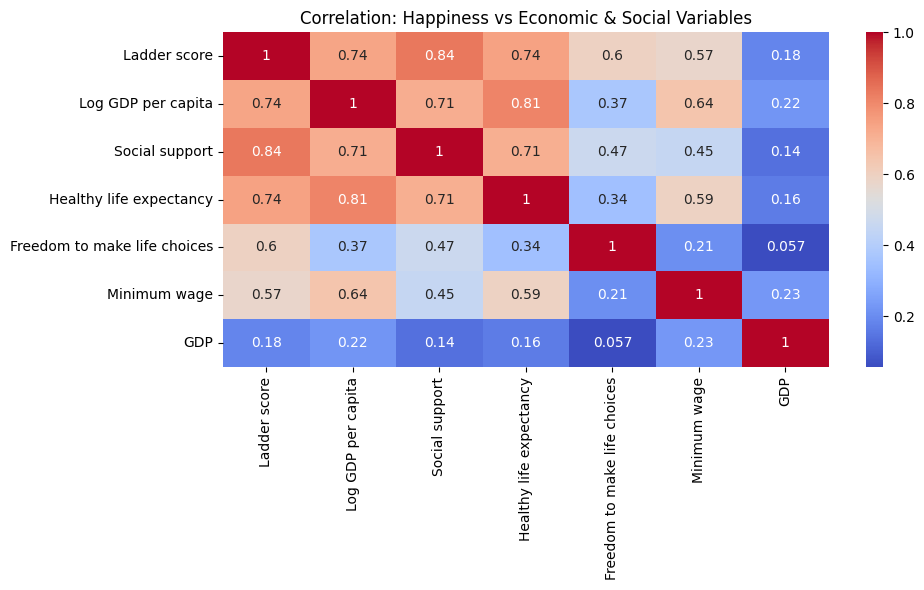

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation: Happiness vs Economic & Social Variables")
plt.tight_layout()
plt.savefig("results/figures/correlation_heatmap.png", dpi=300)
plt.show()


In [10]:
X = analysis_df[[
    "Log GDP per capita",
    "Minimum wage",
    "Healthy life expectancy",
    "Social support",
    "Freedom to make life choices"
]]
y = analysis_df["Ladder score"]

# Add intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           Ladder score   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     93.97
Date:                Tue, 09 Dec 2025   Prob (F-statistic):           5.84e-37
Time:                        21:18:37   Log-Likelihood:                -73.238
No. Observations:                 110   AIC:                             158.5
Df Residuals:                     104   BIC:                             174.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

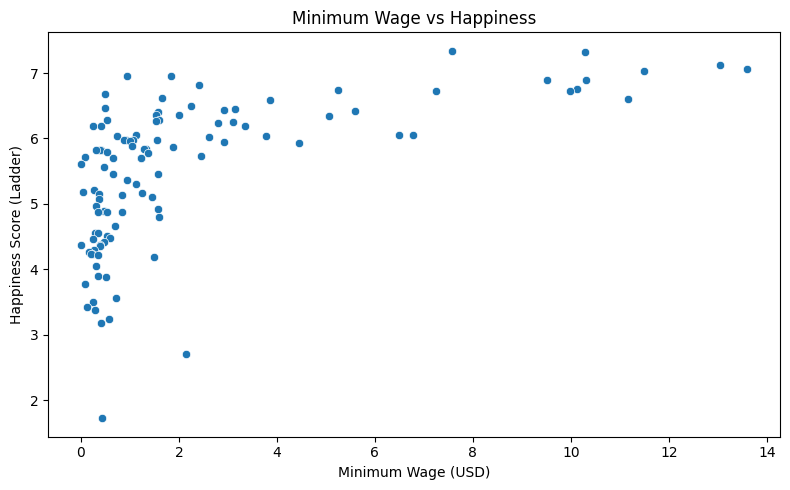

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=analysis_df["Minimum wage"],
    y=analysis_df["Ladder score"]
)
plt.xlabel("Minimum Wage (USD)")
plt.ylabel("Happiness Score (Ladder)")
plt.title("Minimum Wage vs Happiness")
plt.tight_layout()
plt.savefig("results/figures/minwage_vs_happiness.png", dpi=300)
plt.show()


In [12]:
print("Done! Artifacts created:")
print("- Cleaned datasets in data/clean/")
print("- Integrated dataset in data/integrated/")
print("- Correlation heatmap + scatterplot in results/figures/")
print("- Regression summary in results/regression_summary.txt")


Done! Artifacts created:
- Cleaned datasets in data/clean/
- Integrated dataset in data/integrated/
- Correlation heatmap + scatterplot in results/figures/
- Regression summary in results/regression_summary.txt
